# G1 Edge Runtime Diagnostics

Pandas notebook for visualizing topic data, Unitree API services, software and hardware versions, runtime config, and telemetry needed by the G1 edge runtime.

The runtime directory is detected from `dev/edge_runtime`. If you later move it to `modules/edge_runetime`, update `EDGE_RUNTIME_DIR` in the setup cell.

In [1]:
from __future__ import annotations

import json
import os
import platform
import re
import subprocess
import sys
import time
from pathlib import Path
from typing import Any

import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

G1_ROOT = Path.cwd()
if G1_ROOT.name != "g1":
    candidate = Path("/home/unitree/EF/ef_ws/g1")
    if candidate.exists():
        G1_ROOT = candidate

EDGE_RUNTIME_DIR = G1_ROOT / "dev" / "edge_runtime"
MODULES_DIR = G1_ROOT / "modules"
TOPICS_MD = G1_ROOT / "topics.md"
FINGERPRINT_PATH = EDGE_RUNTIME_DIR / "device_identity" / "hardware_fingerprint.json"
USER_CONFIG_PATH = EDGE_RUNTIME_DIR / "device_identity" / "user_config.json"
RUNTIME_CONFIG_PATH = EDGE_RUNTIME_DIR / "config" / "runtime_config.yaml"

sys.path.insert(0, str(MODULES_DIR))
sys.path.insert(0, str(EDGE_RUNTIME_DIR.parent))

paths_df = pd.DataFrame(
    [
        {"name": "g1_root", "path": G1_ROOT, "exists": G1_ROOT.exists()},
        {"name": "edge_runtime", "path": EDGE_RUNTIME_DIR, "exists": EDGE_RUNTIME_DIR.exists()},
        {"name": "modules", "path": MODULES_DIR, "exists": MODULES_DIR.exists()},
        {"name": "topics_md", "path": TOPICS_MD, "exists": TOPICS_MD.exists()},
        {"name": "hardware_fingerprint", "path": FINGERPRINT_PATH, "exists": FINGERPRINT_PATH.exists()},
        {"name": "user_config", "path": USER_CONFIG_PATH, "exists": USER_CONFIG_PATH.exists()},
        {"name": "runtime_config", "path": RUNTIME_CONFIG_PATH, "exists": RUNTIME_CONFIG_PATH.exists()},
    ]
)
paths_df

,name,path,exists
0,g1_root,/home/unitree/EF/ef_ws/g1,True
1,edge_runtime,/home/unitree/EF/ef_ws/g1/dev/edge_runtime,True
2,modules,/home/unitree/EF/ef_ws/g1/modules,True
3,topics_md,/home/unitree/EF/ef_ws/g1/topics.md,True
4,hardware_fingerprint,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/device_identity/hardware_fingerprint.json,True
5,user_config,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/device_identity/user_config.json,True
6,runtime_config,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/config/runtime_config.yaml,True


## Helpers

In [2]:
def load_json(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as handle:
        data = json.load(handle)
    return data if isinstance(data, dict) else {"value": data}


def load_yaml(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {}
    try:
        import yaml
    except ImportError:
        return {"_error": "PyYAML is not installed", "_path": str(path)}
    with path.open("r", encoding="utf-8") as handle:
        data = yaml.safe_load(handle) or {}
    return data if isinstance(data, dict) else {"value": data}


def flatten_dict(data: dict[str, Any], prefix: str = "") -> dict[str, Any]:
    rows: dict[str, Any] = {}
    for key, value in data.items():
        name = f"{prefix}.{key}" if prefix else str(key)
        if isinstance(value, dict):
            rows.update(flatten_dict(value, name))
        else:
            rows[name] = value
    return rows


def dict_to_df(data: dict[str, Any], section: str) -> pd.DataFrame:
    flat = flatten_dict(data)
    rows = [{"section": section, "key": key, "value": value} for key, value in flat.items()]
    return pd.DataFrame(rows, columns=["section", "key", "value"])


def run_cmd(args: list[str], timeout: float = 5.0) -> dict[str, Any]:
    started = time.time()
    try:
        proc = subprocess.run(args, capture_output=True, text=True, timeout=timeout)
        return {
            "cmd": " ".join(args),
            "returncode": proc.returncode,
            "stdout": proc.stdout.strip(),
            "stderr": proc.stderr.strip(),
            "elapsed_s": round(time.time() - started, 3),
        }
    except Exception as exc:
        return {
            "cmd": " ".join(args),
            "returncode": None,
            "stdout": "",
            "stderr": repr(exc),
            "elapsed_s": round(time.time() - started, 3),
        }


def json_safe(value: Any) -> Any:
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if hasattr(value, "tolist"):
        try:
            return json_safe(value.tolist())
        except Exception:
            pass
    if hasattr(value, "__dict__"):
        try:
            return json_safe(vars(value))
        except Exception:
            pass
    return repr(value)

## Runtime Config And Identity

In [3]:
fingerprint = load_json(FINGERPRINT_PATH)
user_config = load_json(USER_CONFIG_PATH)
runtime_config = load_yaml(RUNTIME_CONFIG_PATH)

identity_df = pd.concat(
    [
        dict_to_df(fingerprint, "hardware_fingerprint"),
        dict_to_df(user_config, "user_config"),
        dict_to_df(runtime_config, "runtime_config"),
    ],
    ignore_index=True,
)
identity_df

,section,key,value
0,hardware_fingerprint,manufacturer,Unitree
1,hardware_fingerprint,model,G1
2,hardware_fingerprint,os_version,3.2.1
3,hardware_fingerprint,arm_dof,6
4,hardware_fingerprint,hand_type,5_finger
5,hardware_fingerprint,sensors,"[rgbd_camera, lidar]"
6,hardware_fingerprint,compute,Nvidia Orin
7,hardware_fingerprint,payload_kg,3
8,hardware_fingerprint,firmware_version,1.0.0
9,hardware_fingerprint,battery_capacity,10000mAh


In [4]:
hardware_df = pd.DataFrame(
    [{"key": key, "value": value, "source": "hardware_fingerprint.json"} for key, value in fingerprint.items()]
)
hardware_df

,key,value,source
0,manufacturer,Unitree,hardware_fingerprint.json
1,model,G1,hardware_fingerprint.json
2,os_version,3.2.1,hardware_fingerprint.json
3,arm_dof,6,hardware_fingerprint.json
4,hand_type,5_finger,hardware_fingerprint.json
5,sensors,"[rgbd_camera, lidar]",hardware_fingerprint.json
6,compute,Nvidia Orin,hardware_fingerprint.json
7,payload_kg,3,hardware_fingerprint.json
8,firmware_version,1.0.0,hardware_fingerprint.json
9,battery_capacity,10000mAh,hardware_fingerprint.json


In [5]:
try:
    import edge_runtime
    edge_runtime_version = getattr(edge_runtime, "__version__", None)
except Exception as exc:
    edge_runtime_version = f"unavailable: {exc!r}"

software_rows = [
    {"component": "edge_runtime", "version": edge_runtime_version, "source": str(EDGE_RUNTIME_DIR)},
    {"component": "python", "version": platform.python_version(), "source": sys.executable},
    {"component": "platform", "version": platform.platform(), "source": "platform.platform()"},
    {"component": "os_version", "version": fingerprint.get("os_version"), "source": str(FINGERPRINT_PATH)},
    {"component": "firmware_version", "version": fingerprint.get("firmware_version"), "source": str(FINGERPRINT_PATH)},
    {"component": "fallback_version", "version": runtime_config.get("updates", {}).get("fallback_version") if isinstance(runtime_config.get("updates"), dict) else None, "source": str(RUNTIME_CONFIG_PATH)},
]

for package in ["pandas", "psutil", "aiohttp", "yaml", "rclpy", "unitree_sdk2py"]:
    try:
        module = __import__(package)
        version = getattr(module, "__version__", "installed")
    except Exception as exc:
        version = f"unavailable: {exc.__class__.__name__}"
    software_rows.append({"component": package, "version": version, "source": "python import"})

software_df = pd.DataFrame(software_rows)
software_df

,component,version,source
0,edge_runtime,"unavailable: ImportError(""cannot import name 'hardware_fingerprint' from 'edge_runtime.device_identity' (unknown location)"")",/home/unitree/EF/ef_ws/g1/dev/edge_runtime
1,python,3.8.10,/usr/bin/python3
2,platform,Linux-5.10.104-tegra-aarch64-with-glibc2.29,platform.platform()
3,os_version,3.2.1,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/device_identity/hardware_fingerprint.json
4,firmware_version,1.0.0,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/device_identity/hardware_fingerprint.json
5,fallback_version,3.2.0,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/config/runtime_config.yaml
6,pandas,0.25.3,python import
7,psutil,5.5.1,python import
8,aiohttp,unavailable: ModuleNotFoundError,python import
9,yaml,5.3.1,python import


## Edge Runtime Requirements

In [6]:
requirements_path = EDGE_RUNTIME_DIR / "requirements.txt"
requirements = []
if requirements_path.exists():
    for line in requirements_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            requirements.append(line)

requirements_df = pd.DataFrame({"requirement": requirements})
requirements_df

,requirement
0,numpy
1,pygame
2,pynput
3,unitree_sdk2py
4,aiohttp
5,websocket-client
6,pandas
7,rich
8,pyyaml
9,json5


In [7]:
runtime_files_df = pd.DataFrame(
    [
        {
            "path": path.relative_to(EDGE_RUNTIME_DIR),
            "suffix": path.suffix,
            "size_bytes": path.stat().st_size,
            "modified": pd.to_datetime(path.stat().st_mtime, unit="s"),
        }
        for path in EDGE_RUNTIME_DIR.rglob("*")
        if path.is_file()
    ]
).sort_values("path")
runtime_files_df

,path,suffix,size_bytes,modified
4,README.md,.md,2300,2026-04-27 07:04:04.578991413
1,__init__.py,.py,843,2026-04-27 07:04:04.578991413
6,__pycache__/__init__.cpython-38.pyc,.pyc,1060,2026-05-02 13:03:17.870362759
8,config/runtime_config.yaml,.yaml,695,2026-04-27 07:04:04.578991413
10,device_identity/hardware_fingerprint.json,.json,311,2026-04-27 07:04:04.578991413
9,device_identity/user_config.json,.json,402,2026-04-27 07:04:04.578991413
11,gateway/gateway_client.py,.py,4498,2026-04-27 07:04:04.578991413
0,main.py,.py,3779,2026-04-27 07:04:04.578991413
2,mock_server.py,.py,5692,2026-04-27 07:04:04.578991413
3,requirements.txt,.txt,293,2026-04-27 07:04:04.578991413


## Topic Inventory From `topics.md`

In [8]:
def parse_topics_markdown(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame(columns=["section", "topic", "type", "status", "sample"])

    rows: list[dict[str, Any]] = []
    section = ""
    for raw_line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        line = raw_line.strip()
        if line.startswith("## "):
            section = line[3:].strip()
            continue
        if not line.startswith("|") or "---" in line or line.startswith("| Topic"):
            continue
        parts = [part.strip() for part in line.strip("|").split("|")]
        if len(parts) == 3:
            key = "sample" if section == "Live Topics" else "status"
            rows.append({"section": section, "topic": parts[0].strip("`"), "type": parts[1].strip("`"), key: parts[2]})
        elif len(parts) == 2:
            rows.append({"section": section, "topic": parts[0].strip("`"), "type": parts[1].strip("`")})
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=["section", "topic", "type", "status", "sample"])
    df["is_api"] = df["topic"].str.startswith("/api/")
    df["is_service_state"] = df["topic"].isin(["/servicestate", "/servicestateactivate"])
    df["is_vital"] = df["topic"].str.contains("odom|lowstate|bms|imu|slam|servicestate|robot_state|motion_switcher", case=False, regex=True)
    return df


topics_df = parse_topics_markdown(TOPICS_MD)
topics_df.head(25)

,section,topic,type,sample,status,is_api,is_service_state,is_vital
0,Live Topics,/dog_imu_raw,sensor_msgs/msg/Imu,header: stamp: sec: 1777724672 nanosec: 504264761 frame_id: dog_imu_link orientation: x: -0.0071146320551633835 y: -0.003938368521630764 z: -0.0090323211625...,NaN,False,False,True
1,Live Topics,/dog_odom,nav_msgs/msg/Odometry,header: stamp: sec: 1777724675 nanosec: 433380106 frame_id: odom child_frame_id: robot_center pose: pose: position: x: 0.04996326565742493 y: 0.004511621780...,NaN,False,False,True
2,Live Topics,/lf/bmsstate,unitree_hg/msg/BmsState,version_high: 1 version_low: 6 fn: 5 cell_vol: '<array type: uint16[40]>' bmsvoltage: '<array type: uint32[3]>' current: -2116 soc: 31 soh: 99 temperature: ...,NaN,False,False,True
3,Live Topics,/lf/lowstate,unitree_hg/msg/LowState,version: '<array type: uint32[2]>' mode_pr: 0 mode_machine: 5 tick: 5742548 imu_state: quaternion: '<array type: float[4]>' gyroscope: '<array type: float[3...,NaN,False,False,True
4,Live Topics,/lf/odommodestate,unitree_go/msg/SportModeState,stamp: sec: 0 nanosec: 0 error_code: 0 imu_state: quaternion: '<array type: float[4]>' gyroscope: '<array type: float[3]>' accelerometer: '<array type: floa...,NaN,False,False,True
5,Live Topics,/lowstate,unitree_hg/msg/LowState,version: '<array type: uint32[2]>' mode_pr: 0 mode_machine: 5 tick: 5767555 imu_state: quaternion: '<array type: float[4]>' gyroscope: '<array type: float[3...,NaN,False,False,True
6,Live Topics,/odommodestate,unitree_go/msg/SportModeState,stamp: sec: 0 nanosec: 0 error_code: 0 imu_state: quaternion: '<array type: float[4]>' gyroscope: '<array type: float[3]>' accelerometer: '<array type: floa...,NaN,False,False,True
7,Live Topics,/utlidar/imu_livox_mid360,sensor_msgs/msg/Imu,header: stamp: sec: 1777724823 nanosec: 588977152 frame_id: livox_frame orientation: x: 0.0 y: 0.0 z: 0.0 w: 0.0 orientation_covariance: '<array type: doubl...,NaN,False,False,True
8,"Command, Request, Response, Or Idle System Topics",/api/action_store/request,unitree_api/msg/Request,NaN,COMMAND/REQUEST,True,False,False
9,"Command, Request, Response, Or Idle System Topics",/api/action_store/response,unitree_api/msg/Response,NaN,IDLE RESPONSE,True,False,False


In [10]:
topic_summary_df = (
    topics_df.groupby(["section", "type"])
    .size()
    .reset_index(name="count")
    .sort_values(["section", "count"], ascending=[True, False])
)
topic_summary_df.head(40)

,section,type,count
3,"Command, Request, Response, Or Idle System Topics",unitree_api/msg/Request,26
4,"Command, Request, Response, Or Idle System Topics",unitree_api/msg/Response,24
6,"Command, Request, Response, Or Idle System Topics",unitree_hg/msg/LowCmd,4
5,"Command, Request, Response, Or Idle System Topics",unitree_hg/msg/HandCmd,2
0,"Command, Request, Response, Or Idle System Topics",rcl_interfaces/msg/Log,1
1,"Command, Request, Response, Or Idle System Topics",rcl_interfaces/msg/ParameterEvent,1
2,"Command, Request, Response, Or Idle System Topics",std_msgs/msg/String,1
8,Live Topics,sensor_msgs/msg/Imu,2
9,Live Topics,unitree_go/msg/SportModeState,2
11,Live Topics,unitree_hg/msg/LowState,2


In [11]:
vital_topics = [
    "/lowstate",
    "/lf/lowstate",
    "/lf/bmsstate",
    "/odommodestate",
    "/lf/odommodestate",
    "/dog_odom",
    "/dog_imu_raw",
    "/secondary_imu",
    "/slam_info",
    "/slam_key_info",
    "/servicestate",
    "/servicestateactivate",
    "/api/motion_switcher/request",
    "/api/motion_switcher/response",
    "/api/robot_state/request",
    "/api/robot_state/response",
    "/api/robot_type_service/request",
    "/api/robot_type_service/response",
]

vital_topics_df = topics_df[topics_df["topic"].isin(vital_topics) | topics_df["is_vital"]].copy()
vital_topics_df.sort_values(["section", "topic"])

,section,topic,type,sample,status,is_api,is_service_state,is_vital
39,"Command, Request, Response, Or Idle System Topics",/api/motion_switcher/request,unitree_api/msg/Request,NaN,COMMAND/REQUEST,True,False,True
40,"Command, Request, Response, Or Idle System Topics",/api/motion_switcher/response,unitree_api/msg/Response,NaN,IDLE RESPONSE,True,False,True
42,"Command, Request, Response, Or Idle System Topics",/api/robot_state/request,unitree_api/msg/Request,NaN,COMMAND/REQUEST,True,False,True
43,"Command, Request, Response, Or Idle System Topics",/api/robot_state/response,unitree_api/msg/Response,NaN,IDLE RESPONSE,True,False,True
44,"Command, Request, Response, Or Idle System Topics",/api/robot_type_service/request,unitree_api/msg/Request,NaN,COMMAND/REQUEST,True,False,False
45,"Command, Request, Response, Or Idle System Topics",/api/robot_type_service/response,unitree_api/msg/Response,NaN,IDLE RESPONSE,True,False,False
46,"Command, Request, Response, Or Idle System Topics",/api/slam_operate/request,unitree_api/msg/Request,NaN,COMMAND/REQUEST,True,False,True
47,"Command, Request, Response, Or Idle System Topics",/api/slam_operate/response,unitree_api/msg/Response,NaN,IDLE RESPONSE,True,False,True
0,Live Topics,/dog_imu_raw,sensor_msgs/msg/Imu,header: stamp: sec: 1777724672 nanosec: 504264761 frame_id: dog_imu_link orientation: x: -0.0071146320551633835 y: -0.003938368521630764 z: -0.0090323211625...,NaN,False,False,True
1,Live Topics,/dog_odom,nav_msgs/msg/Odometry,header: stamp: sec: 1777724675 nanosec: 433380106 frame_id: odom child_frame_id: robot_center pose: pose: position: x: 0.04996326565742493 y: 0.004511621780...,NaN,False,False,True


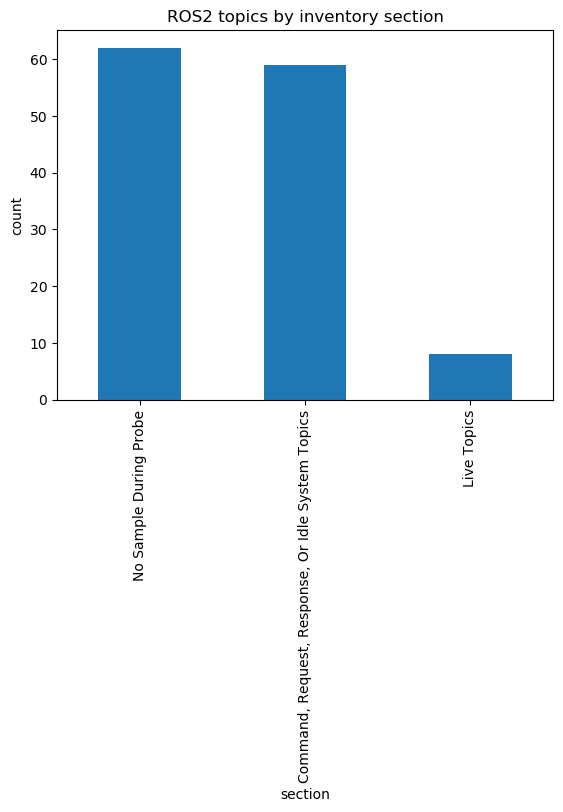

In [12]:
if not topics_df.empty:
    ax = topics_df["section"].value_counts().plot(kind="bar", title="ROS2 topics by inventory section")
    ax.set_xlabel("section")
    ax.set_ylabel("count")

## Unitree API Services And Motion Switcher

In [13]:
api_topics_df = topics_df[topics_df["topic"].str.startswith("/api/", na=False)].copy()
api_topics_df["service"] = api_topics_df["topic"].str.extract(r"^/api/([^/]+)/")
api_topics_df["direction"] = api_topics_df["topic"].str.extract(r"/(request|response)$")

services_df = (
    api_topics_df.pivot_table(index="service", columns="direction", values="topic", aggfunc="first")
    .reset_index()
    .sort_values("service")
)
services_df

direction,service,request,response
0,action_store,/api/action_store/request,/api/action_store/response
1,arm,/api/arm/request,/api/arm/response
2,audiohub,/api/audiohub/request,/api/audiohub/response
3,bashrunner,/api/bashrunner/request,/api/bashrunner/response
4,basic_clearoip,/api/basic_clearoip/request,/api/basic_clearoip/response
5,basic_clearoip_lease,/api/basic_clearoip_lease/request,/api/basic_clearoip_lease/response
6,basic_demarcate,/api/basic_demarcate/request,/api/basic_demarcate/response
7,basic_demarcate_lease,/api/basic_demarcate_lease/request,/api/basic_demarcate_lease/response
8,basic_softlimit,/api/basic_softlimit/request,/api/basic_softlimit/response
9,basic_softlimit_lease,/api/basic_softlimit_lease/request,/api/basic_softlimit_lease/response


In [17]:
def motion_switcher_status(domain_id: int = 0, iface: str | None = None, timeout: float = 5.0) -> dict[str, Any]:
    try:
        from unitree_sdk2py.core.channel import ChannelFactoryInitialize
        from unitree_sdk2py.comm.motion_switcher.motion_switcher_client import MotionSwitcherClient
    except Exception as exc:
        return {"available": False, "error": repr(exc)}

    try:
        if iface:
            ChannelFactoryInitialize(domain_id, iface)
        else:
            ChannelFactoryInitialize(domain_id)
        client = MotionSwitcherClient()
        client.SetTimeout(timeout)
        client.Init()
        code, data = client.CheckMode()
        return {"available": True, "code": code, "data": data}
    except Exception as exc:
        return {"available": False, "error": repr(exc)}


# Set IFACE to the robot network interface before running live checks, for example "eth0".
IFACE = os.environ.get("G1_IFACE") or 'eth0'
DOMAIN_ID = int(os.environ.get("G1_DOMAIN_ID", "0"))

# Uncomment to query the robot:
motion_status = motion_switcher_status(domain_id=DOMAIN_ID, iface=IFACE)
pd.json_normalize(motion_status)


AttributeError: module 'pandas' has no attribute 'json_normalize'

## Live ROS2 Topic Probe

In [18]:
def ros2_topic_list_df(timeout: float = 5.0) -> pd.DataFrame:
    result = run_cmd(["ros2", "topic", "list", "-t"], timeout=timeout)
    rows = []
    for line in result["stdout"].splitlines():
        match = re.match(r"^(\S+)\s+\[(.+)\]$", line.strip())
        if match:
            rows.append({"topic": match.group(1), "type": match.group(2)})
    df = pd.DataFrame(rows)
    df.attrs["command"] = result
    return df


def ros2_topic_echo_once(topic: str, timeout: float = 3.0) -> dict[str, Any]:
    return run_cmd(["timeout", str(timeout), "ros2", "topic", "echo", "--no-arr", topic], timeout=timeout + 2.0)


# Uncomment when ROS2 is sourced in the notebook kernel environment:
live_topics_df = ros2_topic_list_df()
live_topics_df.head(30)

# Example one-shot sample:
sample = ros2_topic_echo_once("/odommodestate")
print(sample["stdout"] or sample["stderr"])


AttributeError: 'DataFrame' object has no attribute 'attrs'

## Robot State And Edge Runtime Payloads

In [19]:
def get_robot_state(iface: str | None = None, domain_id: int = 0) -> dict[str, Any]:
    try:
        from sdk_client import Robot
    except Exception as exc:
        return {"_error": f"sdk_client import failed: {exc!r}"}
    try:
        kwargs = {"domain_id": domain_id, "safety_boot": False, "auto_start_sensors": True}
        if iface:
            kwargs["iface"] = iface
        robot = Robot(**kwargs)
        return json_safe(robot.get_robot_state())
    except Exception as exc:
        return {"_error": repr(exc)}


# Uncomment for a live robot snapshot:
robot_state = get_robot_state(iface=IFACE, domain_id=DOMAIN_ID)
robot_state_df = dict_to_df(robot_state, "robot_state")
robot_state_df


,section,key,value
0,robot_state,fsm.id,0
1,robot_state,fsm.mode,0
2,robot_state,mode,0
3,robot_state,gait,0
4,robot_state,body_height,0
5,robot_state,position,"[-0.002873893827199936, -0.001104468246921897, 0.6827973127365112]"
6,robot_state,velocity,"[-9.177624882283908e-09, 1.1670208266423288e-07, 2.329440576431807e-06]"
7,robot_state,yaw,-0.000529085
8,robot_state,is_moving,False
9,robot_state,imu.rpy,"[-0.0060673728585243225, -0.029490141198039055, -0.0005290854605846107]"


In [20]:
def collect_system_metrics() -> dict[str, Any]:
    try:
        import psutil
        net_io = psutil.net_io_counters()
        return {
            "timestamp": int(time.time()),
            "cpu_usage": psutil.cpu_percent(interval=0.25),
            "memory_usage": psutil.virtual_memory().percent,
            "disk_usage": psutil.disk_usage(os.path.abspath(os.sep)).percent,
            "network_bytes_sent": net_io.bytes_sent,
            "network_bytes_recv": net_io.bytes_recv,
        }
    except Exception as exc:
        return {"_error": repr(exc)}


system_metrics = collect_system_metrics()
system_metrics_df = dict_to_df(system_metrics, "system")
system_metrics_df

,section,key,value
0,system,timestamp,1.777727e+09
1,system,cpu_usage,1.520000e+01
2,system,memory_usage,2.000000e+01
3,system,disk_usage,2.200000e+00
4,system,network_bytes_sent,3.857217e+08
5,system,network_bytes_recv,4.135412e+09


In [21]:
def build_edge_runtime_snapshot(robot_state: dict[str, Any] | None = None) -> dict[str, Any]:
    robot_state = robot_state or {}
    device_id = str(fingerprint.get("device_id") or "G1_Robot_001")
    skill_settings = runtime_config.get("skills", {}) if isinstance(runtime_config.get("skills"), dict) else {}
    updates = runtime_config.get("updates", {}) if isinstance(runtime_config.get("updates"), dict) else {}
    network = runtime_config.get("network", {}) if isinstance(runtime_config.get("network"), dict) else {}
    battery = fingerprint.get("battery_level", fingerprint.get("battery_capacity"))

    hardware = dict(fingerprint)
    hardware.setdefault("manufacturer", "Unitree")
    hardware.setdefault("model", "G1")
    hardware["network_interface"] = IFACE
    hardware["domain_id"] = DOMAIN_ID

    software = {
        "runtime": "altegro_client",
        "runtime_version": edge_runtime_version,
        "platform": platform.platform(),
        "python_version": platform.python_version(),
        "os_version": fingerprint.get("os_version"),
        "firmware_version": fingerprint.get("firmware_version"),
        "skills_repository_path": skill_settings.get("repository_path"),
        "max_concurrent_skills": skill_settings.get("max_concurrent_skills"),
        "default_skill_timeout": skill_settings.get("default_timeout"),
        "fallback_version": updates.get("fallback_version"),
        "network_timeout": network.get("timeout"),
    }

    telemetry = {
        "timestamp": int(time.time()),
        "device_id": device_id,
        "runtime": "altegro_client",
        "system": system_metrics,
        "robot": {
            "fsm": robot_state.get("fsm"),
            "mode": robot_state.get("mode"),
            "gait": robot_state.get("gait"),
            "body_height": robot_state.get("body_height"),
            "position": robot_state.get("position"),
            "velocity": robot_state.get("velocity"),
            "yaw": robot_state.get("yaw"),
            "imu": robot_state.get("imu"),
            "odom_pose": robot_state.get("odom_pose"),
            "slam_pose": robot_state.get("slam_pose"),
            "is_moving": robot_state.get("is_moving"),
            "sensor_stale": robot_state.get("sensor_stale"),
            "sensor_timestamps": robot_state.get("sensor_timestamps"),
            "slam_is_running": robot_state.get("slam_is_running"),
            "queued_path_points": robot_state.get("queued_path_points"),
            "joint_count": robot_state.get("joint_count"),
            "battery": battery,
        },
    }

    return {
        "device_registration": {**hardware, "device_id": device_id, "runtime": "altegro_client"},
        "telemetry": telemetry,
        "heartbeat": {
            "status": "active" if not robot_state.get("_error") else "unavailable",
            "timestamp": int(time.time()),
            "robot_connected": not bool(robot_state.get("_error")),
            "fsm": robot_state.get("fsm"),
            "mode": robot_state.get("mode"),
            "is_moving": robot_state.get("is_moving"),
        },
        "skill_inventory": {"hardware": hardware, "software": software},
    }


edge_snapshot = build_edge_runtime_snapshot(robot_state={})
edge_snapshot_df = pd.concat(
    [dict_to_df(value, key) for key, value in edge_snapshot.items()],
    ignore_index=True,
)
edge_snapshot_df

,section,key,value
0,device_registration,manufacturer,Unitree
1,device_registration,model,G1
2,device_registration,os_version,3.2.1
3,device_registration,arm_dof,6
4,device_registration,hand_type,5_finger
...,...,...,...
66,skill_inventory,software.skills_repository_path,/opt/g1/skills
67,skill_inventory,software.max_concurrent_skills,3
68,skill_inventory,software.default_skill_timeout,300
69,skill_inventory,software.fallback_version,3.2.0


## Vital Runtime Readiness Matrix

In [22]:
required_runtime_items = [
    {"item": "hardware fingerprint", "required_for": "device registration / compatibility", "ok": bool(fingerprint), "source": str(FINGERPRINT_PATH)},
    {"item": "runtime config", "required_for": "gateway, skills, update policy", "ok": bool(runtime_config), "source": str(RUNTIME_CONFIG_PATH)},
    {"item": "MotionSwitcher API", "required_for": "service/mode activation", "ok": "/api/motion_switcher/request" in set(topics_df.get("topic", [])), "source": "topics.md"},
    {"item": "robot_state API", "required_for": "robot status", "ok": "/api/robot_state/request" in set(topics_df.get("topic", [])), "source": "topics.md"},
    {"item": "robot_type API", "required_for": "model/type discovery", "ok": "/api/robot_type_service/request" in set(topics_df.get("topic", [])), "source": "topics.md"},
    {"item": "odom mode topic", "required_for": "position/motion telemetry", "ok": "/odommodestate" in set(topics_df.get("topic", [])), "source": "topics.md"},
    {"item": "lowstate topic", "required_for": "joint/battery/IMU telemetry", "ok": "/lowstate" in set(topics_df.get("topic", [])), "source": "topics.md"},
    {"item": "SLAM info topic", "required_for": "mapping/navigation telemetry", "ok": "/slam_info" in set(topics_df.get("topic", [])), "source": "topics.md"},
    {"item": "service state topics", "required_for": "robot service activation visibility", "ok": {"/servicestate", "/servicestateactivate"}.issubset(set(topics_df.get("topic", []))), "source": "topics.md"},
]

readiness_df = pd.DataFrame(required_runtime_items)
readiness_df

,item,required_for,ok,source
0,hardware fingerprint,device registration / compatibility,True,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/device_identity/hardware_fingerprint.json
1,runtime config,"gateway, skills, update policy",True,/home/unitree/EF/ef_ws/g1/dev/edge_runtime/config/runtime_config.yaml
2,MotionSwitcher API,service/mode activation,True,topics.md
3,robot_state API,robot status,True,topics.md
4,robot_type API,model/type discovery,True,topics.md
5,odom mode topic,position/motion telemetry,True,topics.md
6,lowstate topic,joint/battery/IMU telemetry,True,topics.md
7,SLAM info topic,mapping/navigation telemetry,True,topics.md
8,service state topics,robot service activation visibility,True,topics.md


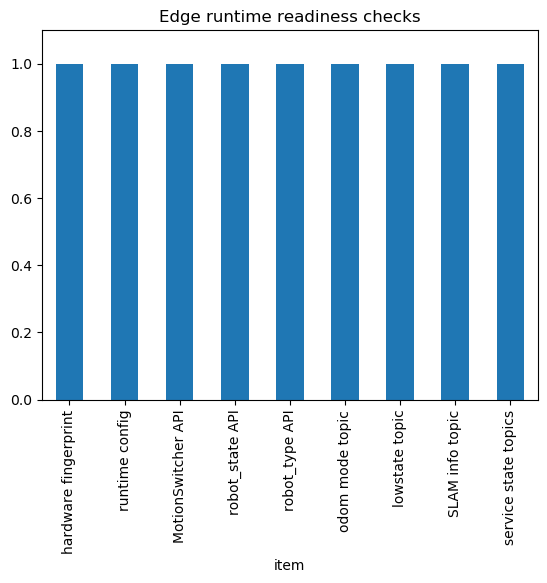

In [23]:
readiness_df.assign(ok_int=readiness_df["ok"].astype(int)).plot(
    x="item", y="ok_int", kind="bar", legend=False, title="Edge runtime readiness checks", ylim=(0, 1.1)
);